In [1]:
from Imports import *
from Helper import *
from Preprocessing import *
from Plotting import *
%matplotlib inline

In [2]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
jet_images_path = '../data/jet-images_Mass60-100_pT250-300_R1.25_Pix25.hdf5'
jet_mass_data = HDF5File(jet_images_path, 'r')

print(jet_mass_data.keys())
print(jet_mass_data['image'].shape)

<KeysViewHDF5 ['image', 'jet_delta_R', 'jet_eta', 'jet_mass', 'jet_phi', 'jet_pt', 'signal', 'tau_1', 'tau_2', 'tau_21', 'tau_3', 'tau_32']>
(872666, 25, 25)


In [3]:
class Generator(nn.Module):
    def __init__(self, latent_dim=256):
        super().__init__()
        self.latent_dim = latent_dim

        self.noise = GaussianNoise(sigma=0.1)

        self.feature_gen = nn.Sequential(
            nn.Linear(9, 64),
            nn.ReLU(True),
            nn.Linear(64, 256),
            nn.LayerNorm(256),
            self.noise
        )

        self.image_gen1 = nn.Sequential(
            nn.ConvTranspose2d(256, 128, kernel_size=4, stride=2, padding=1),  # 1x1 → 2x2
            nn.BatchNorm2d(128),
            nn.ReLU(True),
            nn.Dropout(0.2),
        )
        self.image_gen2 = nn.Sequential(
            nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1),   # 2x2 → 4x4
            nn.BatchNorm2d(64),
            nn.ReLU(True),
            nn.Dropout(0.2),
        )
        self.image_gen3 = nn.Sequential(
            nn.ConvTranspose2d(64, 32, kernel_size=4, stride=2, padding=1),     # 4x4 → 8x8
            nn.BatchNorm2d(32),
            nn.ReLU(True),
            nn.Dropout(0.2),
        )

        self.image_gen4 = nn.Sequential(
            nn.ConvTranspose2d(32, 1, kernel_size=4, stride=2, padding=1),     # 8x8 → 16x16
            nn.Sigmoid()
        )

    def forward(self, z_feat):
        img = self.feature_gen(z_feat)
        # print(img.shape)
        img = img.view(-1, 256, 1, 1)
        # print(img.shape)
        img = self.image_gen1(img)
        # print(img.shape)
        img = self.image_gen2(img)
        # print(img.shape)
        img = self.image_gen3(img)
        # print(img.shape)
        img = self.image_gen4(img)
        # print(img.shape)
        img = soft_threshold(img, threshold=0.001, sharpness=1000.0)
        return img


class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        
        # Flattened image: 16x16 = 256
        self.image_encoder = nn.Sequential(
            spectral_norm(nn.Conv2d(1, 64, 4, 2, 1, bias=False)),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Dropout(0.2),
            spectral_norm(nn.Conv2d(64, 128, 4, 2, 1, bias=False)),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Dropout(0.2),
            spectral_norm(nn.Conv2d(128, 256, 4, 2, 1, bias=False)),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Dropout(0.2),
            nn.Flatten()
        )

        self.feature_encoder = nn.Sequential(
            nn.Linear(4, 64),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.2),
            nn.Linear(64, 128),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.2),
        )

        # Dynamically get input dimensions
        with torch.no_grad():
            dummy = torch.zeros(1, 1, 16, 16)
            flat_dim = self.image_encoder(dummy).shape[1] + 128

        # Combined classifier
        self.classifier = nn.Sequential(
            nn.Linear(flat_dim, 256),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.2),
            nn.Linear(256, 64),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.2),
            nn.Linear(64, 1),
            nn.Sigmoid()
        )

    def forward(self, img, features):
        img_encoded = self.image_encoder(img)
        feat_encoded = self.feature_encoder(features)
        combined = torch.cat((img_encoded, feat_encoded), dim=1)

        # print(img_encoded.shape)
        # print(feat_encoded.shape)
        # print(combined.shape[-1])

        prob = self.classifier(combined)

        return prob  # Shape: (batch_size, 1)

Image shape: torch.Size([872666, 16, 16])
dR Mean: torch.Size([872666])
dR STD: torch.Size([872666])
Pixel Mean: torch.Size([872666])
Pixel STD: torch.Size([872666])
ΔR min: 0.0
ΔR max: 2.4713454246520996
ΔR mean min: 0.003572926390916109
ΔR mean max: 0.015763528645038605
ΔR std min: 0.017520317807793617
ΔR std max: 0.16022197902202606
Weights (pixel intensity) min: 0.0
Weights (pixel intensity) max: 1.0
Pixel mean min: 0.0028264394495636225
Pixel mean max: 0.004322932101786137
Pixel std min: 0.008012386038899422
Pixel std max: 0.06249340996146202


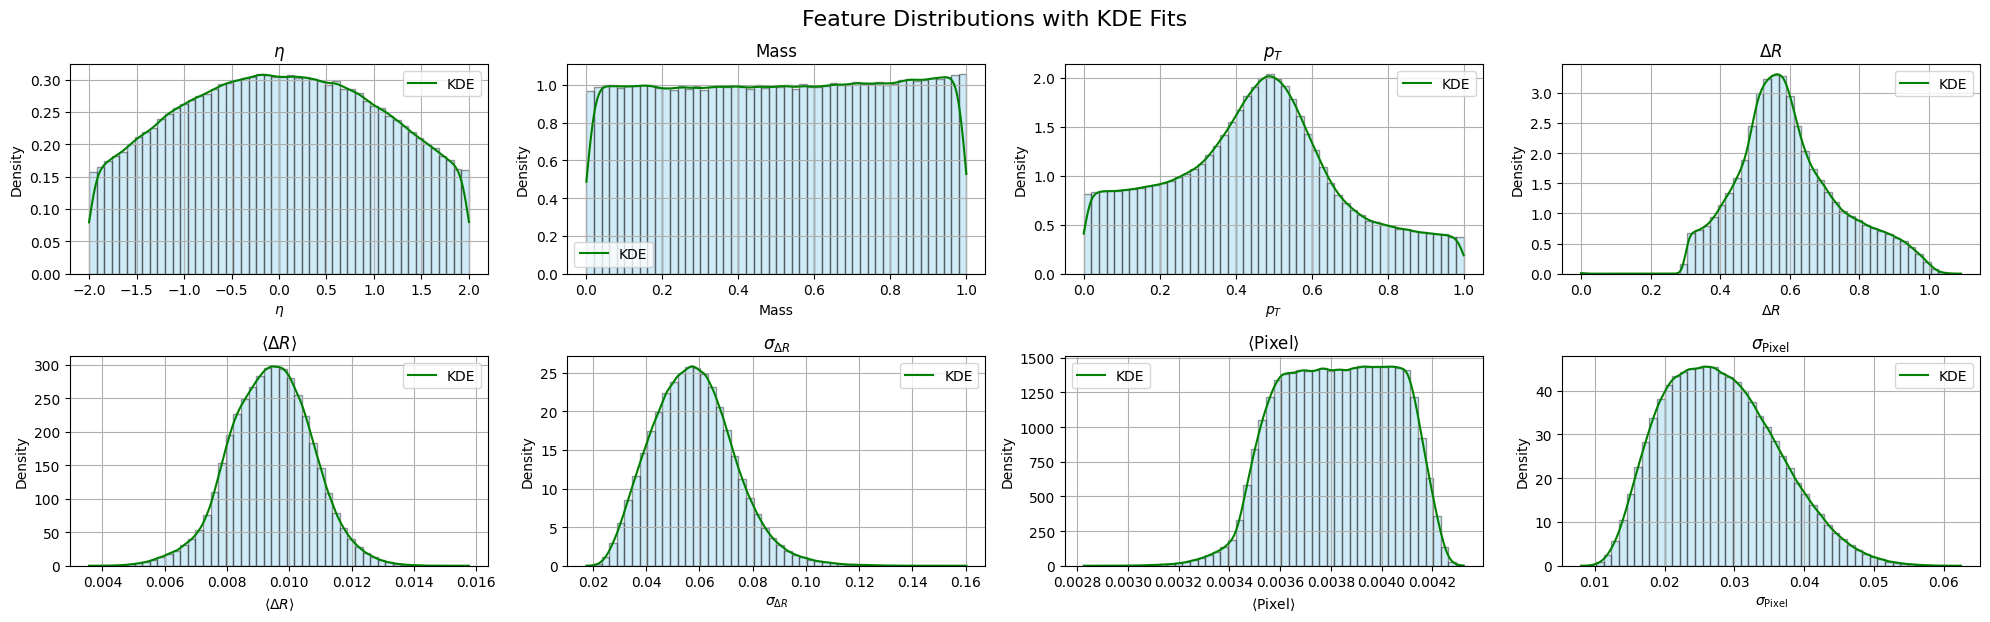

Number of samples: 872666
Image shape: torch.Size([872666, 16, 16])
Feature shape: torch.Size([872666, 9])


In [4]:
batch_size = 128
n_events = int(1 * jet_mass_data['image'].shape[0])

latent_dim = 256
lr = 1e-3
n_epochs = 100
num = 4

dataset = JetDataset(jet_mass_data, n_events)
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True, drop_last=True)

kdes = feature_distributions(dataset)

print("Number of samples:", len(dataset))
print("Image shape:", dataset.images.shape)
print("Feature shape:", dataset.features.shape)

In [5]:
generator = Generator(latent_dim).to(device)
discriminator = Discriminator().to(device)

optimizer_D = optim.Adam(discriminator.parameters(), lr=lr, betas=(0.9, 0.999))
optimizer_G = optim.Adam(generator.parameters(), lr=lr, betas=(0.9, 0.999))

scheduler_G = CosineAnnealingLR(optimizer_G, T_max=n_epochs, eta_min=1e-4)
scheduler_D = CosineAnnealingLR(optimizer_D, T_max=n_epochs, eta_min=1e-4)

g_losses = []
d_losses = []

# Tracking buffers
stats_dict = {
    'fake_dR_mean': [],
    'fake_dR_std': [],
    'fake_pixel_mean': [],
    'fake_pixel_std': [],
    'real_dR_mean': [],
    'real_dR_std': [],
    'real_pixel_mean': [],
    'real_pixel_std': []
}

dists = compute_distance_map(16,16).to(device)

In [6]:
## Load a previous model
# Replace with the desired filename
load = True

if load:
    load_path = "models/class_gan_model_m21_1003.pt"
    # Load the checkpoint
    checkpoint = torch.load(load_path)
    
    # Restore model weights
    generator.load_state_dict(checkpoint["generator_state_dict"])
    discriminator.load_state_dict(checkpoint["discriminator_state_dict"])
    
    # Optionally restore tracking data
    g_losses = checkpoint["g_losses"]
    d_losses = checkpoint["d_losses"]
    
    stats_dict = checkpoint["stats_dict"]
    
    print(f"Loaded model from {load_path}")

Loaded model from models/class_gan_modelm18_1819.pt


[Epoch 1/100] [D loss: 0.4421] [G loss: 1.2277] [Validity_loss: 1.0066] 
 [Stat_loss: 0.1625] [NNZ_loss: 0.0585]
Sample feature coding: [ 1.         -0.32162297  0.98114455  0.14595467  0.6068518   0.01015127
  0.05269101  0.00371326  0.02479237]


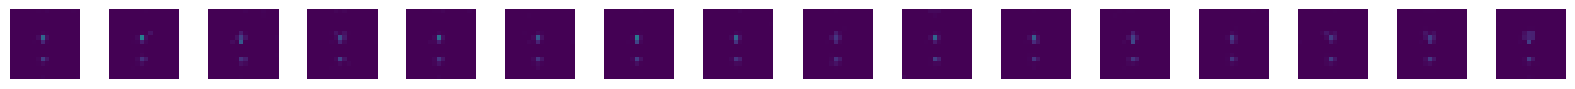

Model and statistics saved to models/class_gan_model_temp.pt
[Epoch 2/100] [D loss: 0.4279] [G loss: 2.0415] [Validity_loss: 1.0547] 
 [Stat_loss: 0.9170] [NNZ_loss: 0.0698]
Sample feature coding: [ 0.         -1.3938379   0.23607078  0.01920785  0.51387286  0.00878041
  0.07695974  0.0035984   0.03325896]


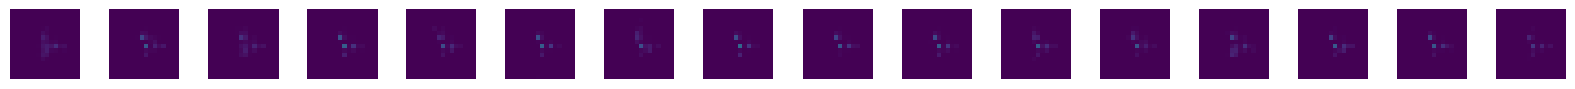

[Epoch 3/100] [D loss: 0.5131] [G loss: 1.0235] [Validity_loss: 0.9435] 
 [Stat_loss: 0.0095] [NNZ_loss: 0.0706]
Sample feature coding: [1.         0.31383133 0.47912592 0.12024556 0.42805353 0.00855772
 0.04780401 0.00401481 0.03540323]


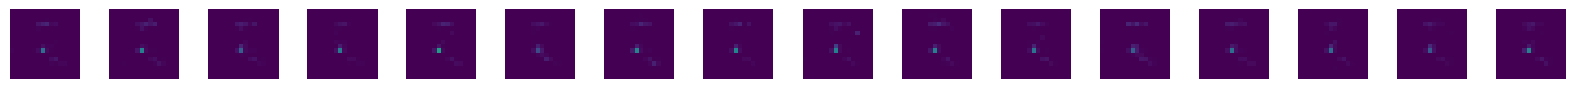

[Epoch 4/100] [D loss: 0.4755] [G loss: 1.1009] [Validity_loss: 0.9085] 
 [Stat_loss: 0.1329] [NNZ_loss: 0.0595]
Sample feature coding: [ 0.         -1.7247574   0.7024441   0.2955481   0.5474437   0.00909065
  0.06009458  0.00347573  0.0297584 ]


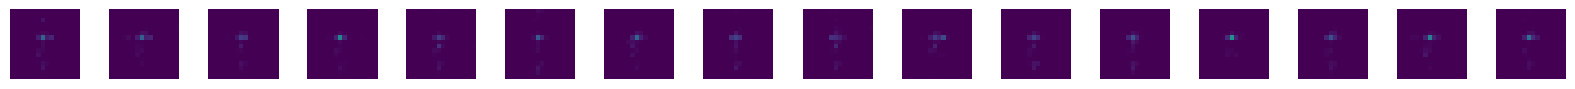

[Epoch 5/100] [D loss: 0.4403] [G loss: 1.1093] [Validity_loss: 0.9724] 
 [Stat_loss: 0.0795] [NNZ_loss: 0.0575]
Sample feature coding: [0.         1.3824924  0.32539392 0.33099338 0.84745955 0.00910892
 0.06960613 0.00387304 0.02028945]


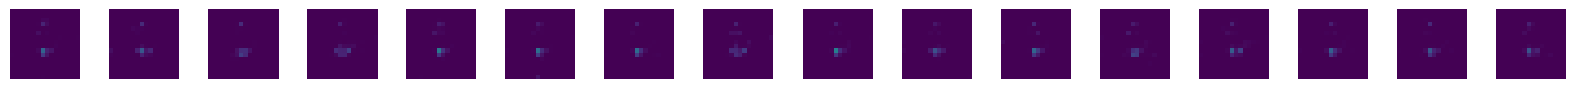

[Epoch 6/100] [D loss: 0.6013] [G loss: 0.9408] [Validity_loss: 0.7839] 
 [Stat_loss: 0.0839] [NNZ_loss: 0.0731]
Sample feature coding: [1.         0.10699712 0.54924273 0.90503603 0.72904986 0.00997123
 0.05494093 0.00382411 0.02238781]


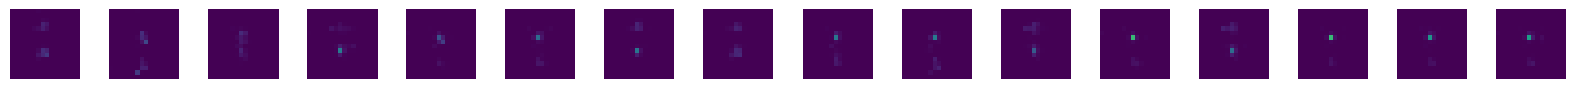

[Epoch 7/100] [D loss: 0.5680] [G loss: 1.0144] [Validity_loss: 0.9080] 
 [Stat_loss: 0.0293] [NNZ_loss: 0.0771]
Sample feature coding: [0.         0.68027663 0.29699618 0.55707747 0.82784975 0.01021778
 0.0485567  0.00396032 0.03726698]


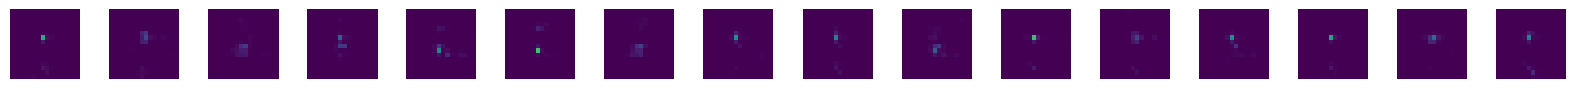

[Epoch 8/100] [D loss: 0.5435] [G loss: 1.0364] [Validity_loss: 0.8899] 
 [Stat_loss: 0.0835] [NNZ_loss: 0.0630]
Sample feature coding: [ 1.         -0.894874    0.21515048  0.4749453   0.5889225   0.00933708
  0.04278531  0.00384582  0.02245283]


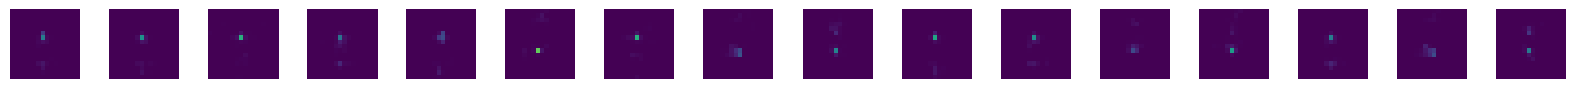

[Epoch 9/100] [D loss: 0.6425] [G loss: 1.0961] [Validity_loss: 0.9023] 
 [Stat_loss: 0.1180] [NNZ_loss: 0.0758]
Sample feature coding: [0.         1.6249471  0.365011   0.13454151 0.5202206  0.01144449
 0.04173335 0.00377784 0.04194279]


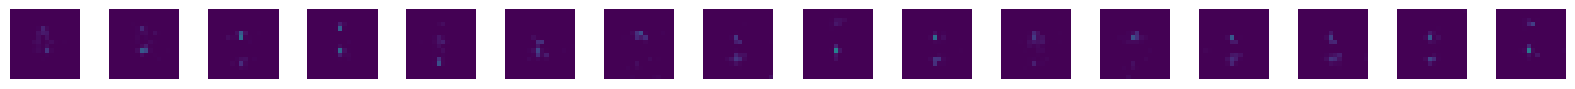

[Epoch 10/100] [D loss: 0.5298] [G loss: 0.9629] [Validity_loss: 0.8267] 
 [Stat_loss: 0.0530] [NNZ_loss: 0.0832]
Sample feature coding: [ 0.         -0.85801214  0.44401684  0.6775889   0.75763535  0.00737686
  0.07164729  0.004143    0.02561011]


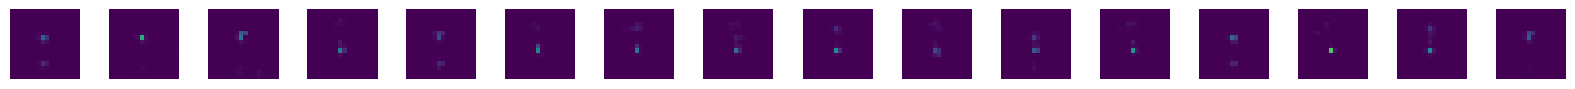

[Epoch 11/100] [D loss: 0.6299] [G loss: 0.8907] [Validity_loss: 0.7942] 
 [Stat_loss: 0.0082] [NNZ_loss: 0.0883]
Sample feature coding: [ 1.         -1.7110599   0.04073073  0.34986666  0.80337137  0.01041412
  0.04191016  0.00374149  0.01727901]


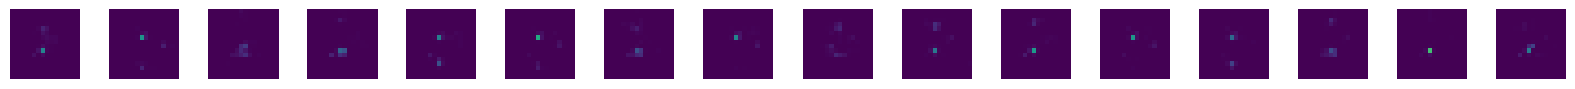

Model and statistics saved to models/class_gan_model_temp.pt
[Epoch 12/100] [D loss: 0.6443] [G loss: 0.8781] [Validity_loss: 0.7825] 
 [Stat_loss: 0.0359] [NNZ_loss: 0.0598]
Sample feature coding: [ 0.         -1.4543455   0.22472762  0.5362649   0.5583918   0.00950406
  0.05982101  0.00385209  0.02450139]


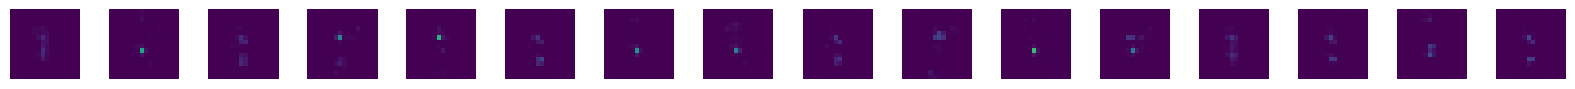

[Epoch 13/100] [D loss: 0.5427] [G loss: 1.0142] [Validity_loss: 0.9479] 
 [Stat_loss: 0.0025] [NNZ_loss: 0.0638]
Sample feature coding: [1.         1.0081927  1.0274523  0.2708276  0.89258456 0.01094168
 0.07488899 0.00411941 0.02885595]


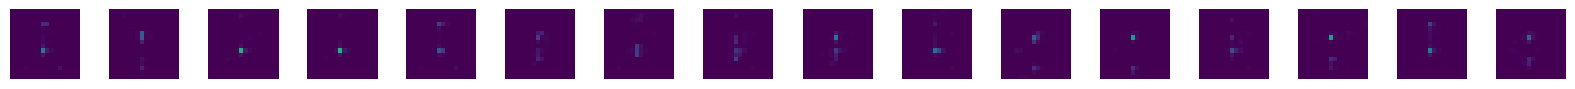

[Epoch 14/100] [D loss: 0.5940] [G loss: 0.9445] [Validity_loss: 0.8697] 
 [Stat_loss: 0.0077] [NNZ_loss: 0.0671]
Sample feature coding: [0.         0.70815444 0.79749644 0.44866163 0.5356897  0.00874554
 0.05552245 0.00371678 0.02762533]


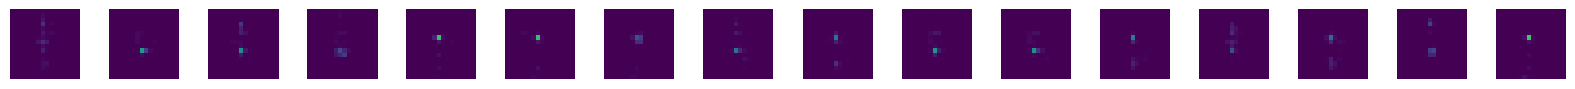

[Epoch 15/100] [D loss: 0.5951] [G loss: 1.0908] [Validity_loss: 0.9812] 
 [Stat_loss: 0.0098] [NNZ_loss: 0.0998]
Sample feature coding: [0.         0.12029957 0.9659627  0.21644324 0.7099975  0.01036319
 0.03698794 0.00396792 0.03431649]


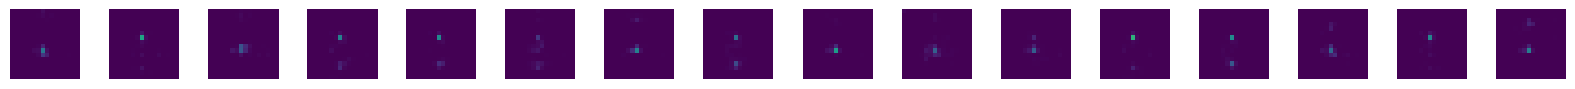

[Epoch 16/100] [D loss: 0.5702] [G loss: 0.9954] [Validity_loss: 0.8889] 
 [Stat_loss: 0.0487] [NNZ_loss: 0.0578]
Sample feature coding: [1.         0.6415545  0.17792882 0.42226934 0.673825   0.00781045
 0.03667443 0.00407806 0.03519891]


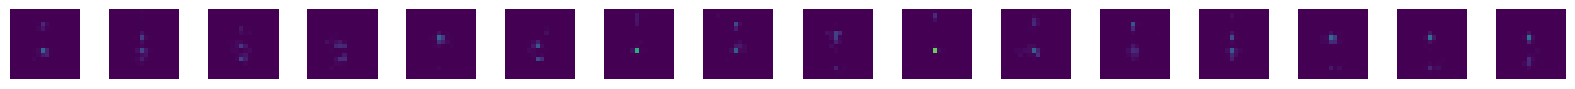

[Epoch 17/100] [D loss: 0.6038] [G loss: 0.8678] [Validity_loss: 0.7480] 
 [Stat_loss: 0.0513] [NNZ_loss: 0.0685]
Sample feature coding: [1.         0.391764   0.5365039  0.41394672 0.47085467 0.00898865
 0.05982259 0.00409713 0.02575516]


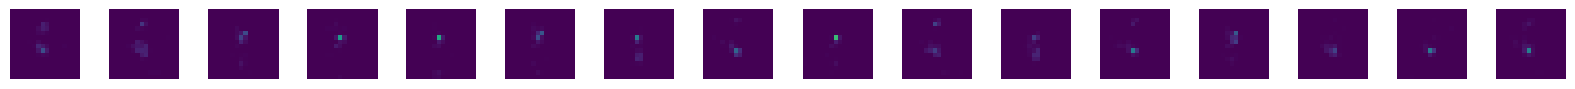

[Epoch 18/100] [D loss: 0.6542] [G loss: 0.9552] [Validity_loss: 0.8340] 
 [Stat_loss: 0.0456] [NNZ_loss: 0.0755]
Sample feature coding: [ 0.         -1.6099774   0.98060066  0.29670876  0.5599376   0.00841428
  0.05710212  0.00408924  0.03480962]


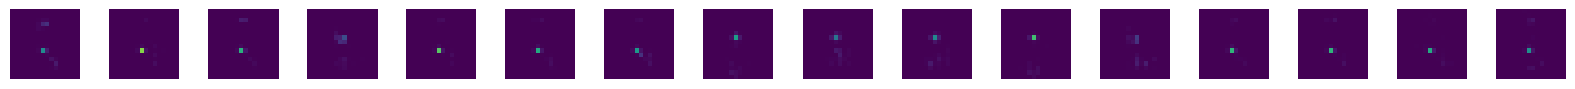

[Epoch 19/100] [D loss: 0.5898] [G loss: 0.9875] [Validity_loss: 0.9104] 
 [Stat_loss: 0.0193] [NNZ_loss: 0.0578]
Sample feature coding: [0.         0.6705079  0.89698845 0.46806756 0.94845617 0.01052556
 0.0421148  0.00359749 0.03237015]


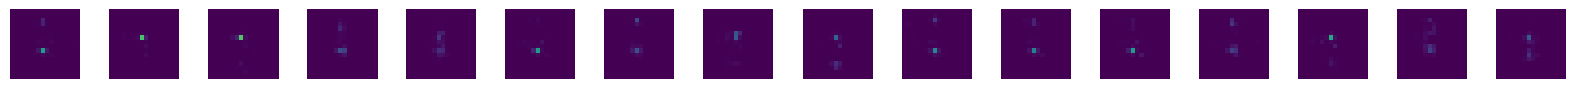

[Epoch 20/100] [D loss: 0.6008] [G loss: 0.9648] [Validity_loss: 0.8533] 
 [Stat_loss: 0.0337] [NNZ_loss: 0.0778]
Sample feature coding: [0.         0.9874248  0.75328434 0.96869713 0.8881118  0.00998694
 0.06555888 0.00414121 0.016669  ]


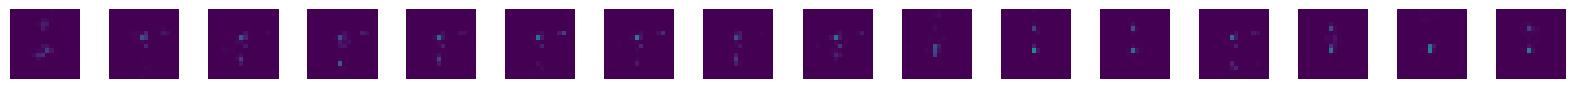

[Epoch 21/100] [D loss: 0.5607] [G loss: 0.9172] [Validity_loss: 0.8357] 
 [Stat_loss: 0.0026] [NNZ_loss: 0.0789]
Sample feature coding: [ 1.         -1.5151182   0.5391641   0.7860917   0.5648474   0.00884482
  0.06289971  0.00396562  0.03426185]


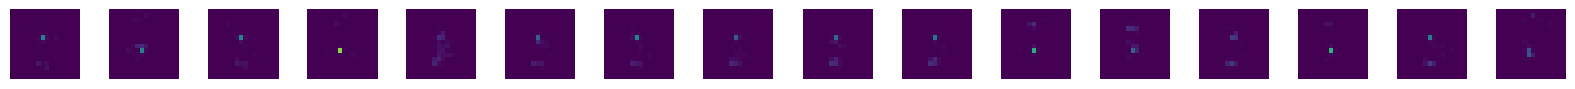

Model and statistics saved to models/class_gan_model_temp.pt
[Epoch 22/100] [D loss: 0.5932] [G loss: 0.8936] [Validity_loss: 0.8097] 
 [Stat_loss: 0.0153] [NNZ_loss: 0.0686]
Sample feature coding: [0.         0.8108761  0.5035824  0.65039146 0.6169999  0.00956725
 0.07676114 0.00392515 0.03629781]


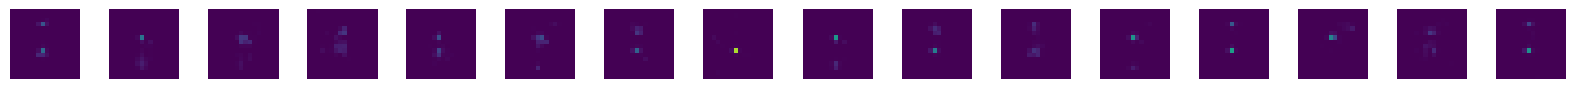

[Epoch 23/100] [D loss: 0.5934] [G loss: 0.9598] [Validity_loss: 0.8643] 
 [Stat_loss: 0.0006] [NNZ_loss: 0.0949]
Sample feature coding: [0.         0.32138178 0.30161738 0.74661547 0.5932263  0.00818557
 0.0696265  0.0041507  0.02235794]


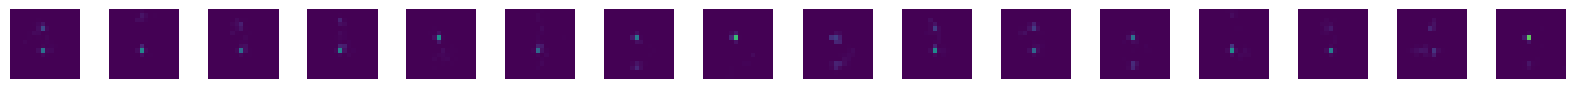

[Epoch 24/100] [D loss: 0.5947] [G loss: 0.9835] [Validity_loss: 0.8620] 
 [Stat_loss: 0.0446] [NNZ_loss: 0.0769]
Sample feature coding: [1.         1.3624359  0.5659231  0.40833113 0.5172058  0.00961114
 0.039702   0.00357234 0.01239063]


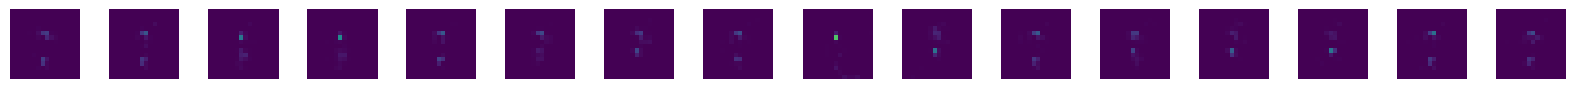

[Epoch 25/100] [D loss: 0.5770] [G loss: 1.0796] [Validity_loss: 0.9851] 
 [Stat_loss: 0.0232] [NNZ_loss: 0.0713]
Sample feature coding: [ 0.         -0.9962059   0.57875705  0.93058866  0.3251003   0.00909861
  0.04519091  0.00381055  0.0153507 ]


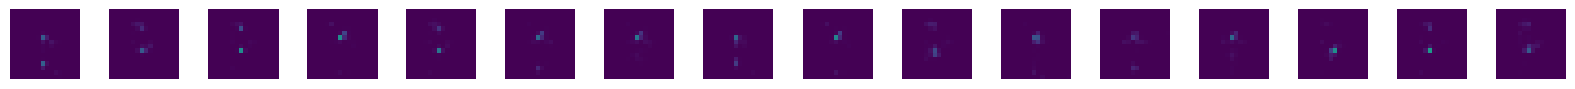

[Epoch 26/100] [D loss: 0.6110] [G loss: 0.9658] [Validity_loss: 0.8636] 
 [Stat_loss: 0.0107] [NNZ_loss: 0.0915]
Sample feature coding: [1.         0.5572758  0.47588938 0.7097228  0.6233641  0.00900956
 0.06117086 0.0037922  0.01641534]


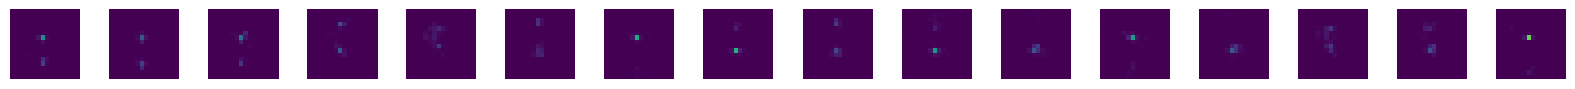

[Epoch 27/100] [D loss: 0.5454] [G loss: 0.9260] [Validity_loss: 0.7928] 
 [Stat_loss: 0.0595] [NNZ_loss: 0.0738]
Sample feature coding: [ 0.         -1.0093215   0.56318396  0.5454414   0.5910692   0.0112887
  0.0853767   0.00396574  0.0320382 ]


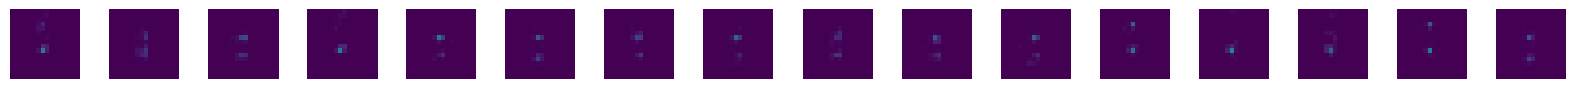

[Epoch 28/100] [D loss: 0.5925] [G loss: 0.9674] [Validity_loss: 0.8639] 
 [Stat_loss: 0.0094] [NNZ_loss: 0.0941]
Sample feature coding: [1.         1.0937688  0.81902874 0.4834739  0.98400277 0.01036837
 0.05817894 0.00333157 0.02520001]


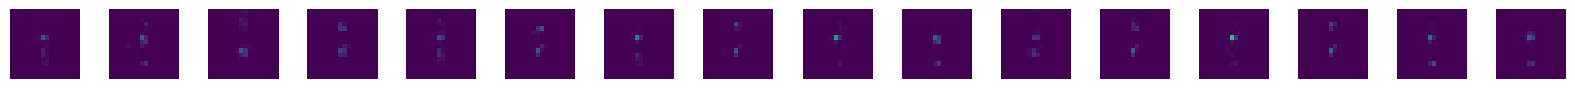

[Epoch 29/100] [D loss: 0.5517] [G loss: 0.9941] [Validity_loss: 0.8715] 
 [Stat_loss: 0.0273] [NNZ_loss: 0.0953]
Sample feature coding: [ 1.         -0.53025675  0.9459898   0.49813694  0.60836095  0.00987749
  0.04816893  0.00382864  0.02390819]


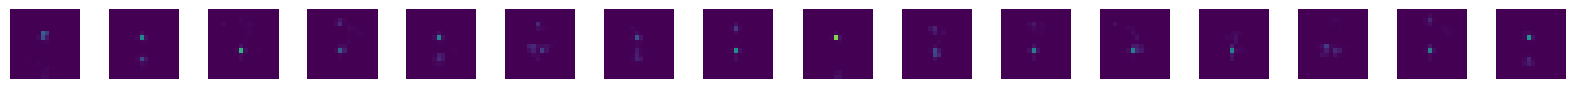

[Epoch 30/100] [D loss: 0.5318] [G loss: 1.0326] [Validity_loss: 0.9367] 
 [Stat_loss: 0.0280] [NNZ_loss: 0.0679]
Sample feature coding: [ 1.         -0.87739563  0.582152    0.24826904  0.41121727  0.01104581
  0.06088595  0.00377955  0.02754156]


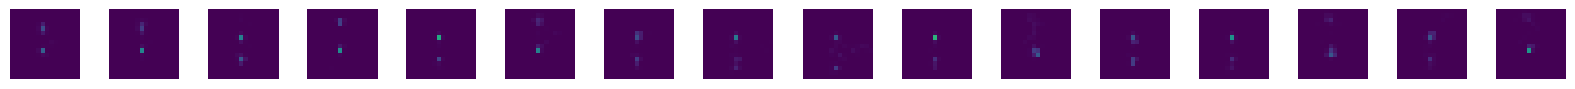

[Epoch 31/100] [D loss: 0.5587] [G loss: 1.0224] [Validity_loss: 0.9513] 
 [Stat_loss: 0.0137] [NNZ_loss: 0.0574]
Sample feature coding: [0.         0.73716843 0.93278176 0.14823304 0.67563283 0.00822789
 0.078399   0.00361829 0.02065938]


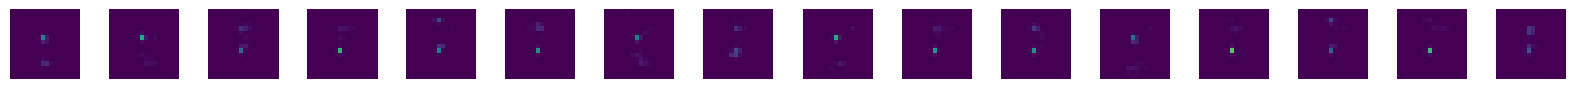

Model and statistics saved to models/class_gan_model_temp.pt
[Epoch 32/100] [D loss: 0.5384] [G loss: 0.9578] [Validity_loss: 0.8706] 
 [Stat_loss: 0.0046] [NNZ_loss: 0.0826]
Sample feature coding: [ 0.         -0.79471034  0.751294    0.17002146  0.5302667   0.00884422
  0.0561566   0.00363715  0.02539458]


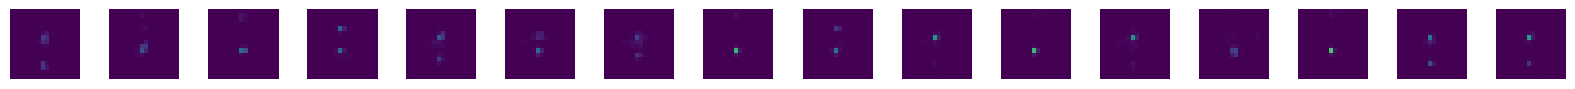

[Epoch 33/100] [D loss: 0.5918] [G loss: 0.9819] [Validity_loss: 0.9017] 
 [Stat_loss: 0.0121] [NNZ_loss: 0.0681]
Sample feature coding: [ 1.         -0.8069168   0.26176673  0.49545896  0.50602     0.00972998
  0.03120368  0.00400159  0.02950543]


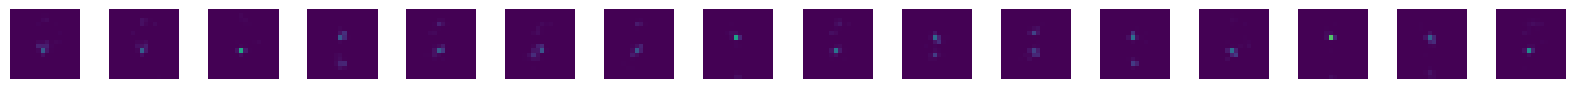

[Epoch 34/100] [D loss: 0.5504] [G loss: 1.1232] [Validity_loss: 1.0074] 
 [Stat_loss: 0.0105] [NNZ_loss: 0.1053]
Sample feature coding: [ 1.         -1.1714963   0.13836887  0.9131093   0.54242414  0.00965122
  0.05235226  0.00401426  0.03810318]


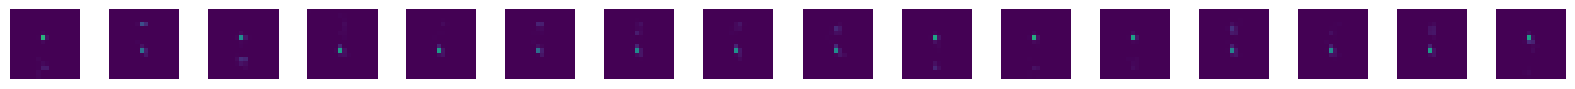

[Epoch 35/100] [D loss: 0.4452] [G loss: 1.1834] [Validity_loss: 1.0483] 
 [Stat_loss: 0.0486] [NNZ_loss: 0.0864]
Sample feature coding: [ 0.         -0.08474232  0.690026    0.31495538  0.6230997   0.01031738
  0.05091018  0.00336289  0.02066223]


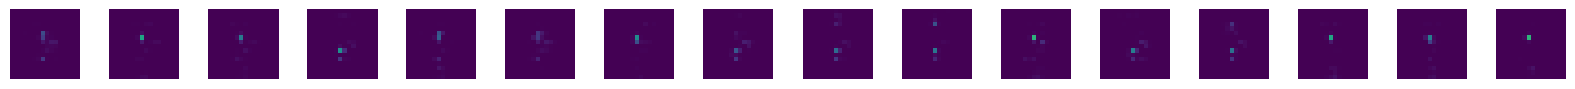

[Epoch 36/100] [D loss: 0.5616] [G loss: 0.9958] [Validity_loss: 0.9158] 
 [Stat_loss: 0.0013] [NNZ_loss: 0.0787]
Sample feature coding: [ 1.         -0.53709626  0.17085232  0.45246166  0.39447594  0.00736033
  0.05613032  0.00359655  0.04119277]


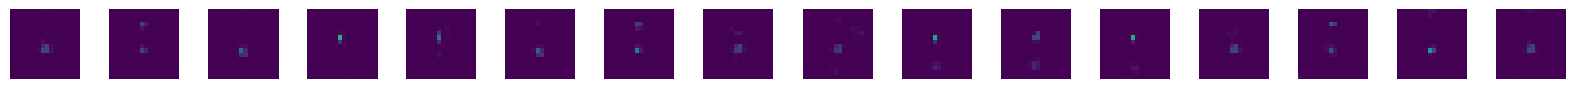

[Epoch 37/100] [D loss: 0.6150] [G loss: 1.0838] [Validity_loss: 0.8880] 
 [Stat_loss: 0.1047] [NNZ_loss: 0.0911]
Sample feature coding: [1.         0.8700377  0.13004701 0.05944621 0.31175685 0.00800241
 0.05993633 0.00352321 0.02021436]


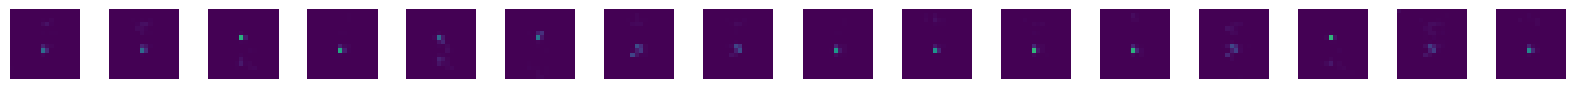

[Epoch 38/100] [D loss: 0.5471] [G loss: 0.9789] [Validity_loss: 0.8780] 
 [Stat_loss: 0.0201] [NNZ_loss: 0.0808]
Sample feature coding: [ 1.         -1.6174823   0.74961066  0.28648815  0.5184542   0.00976096
  0.0762767   0.00382183  0.0281617 ]


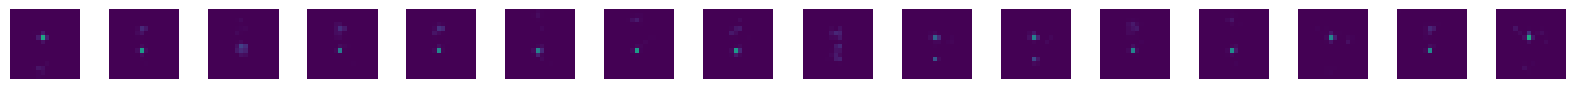

[Epoch 39/100] [D loss: 0.5466] [G loss: 1.3850] [Validity_loss: 1.0286] 
 [Stat_loss: 0.3035] [NNZ_loss: 0.0529]
Sample feature coding: [1.         1.05261    0.85894555 0.25761938 0.4463234  0.01134583
 0.06665467 0.00392466 0.04172491]


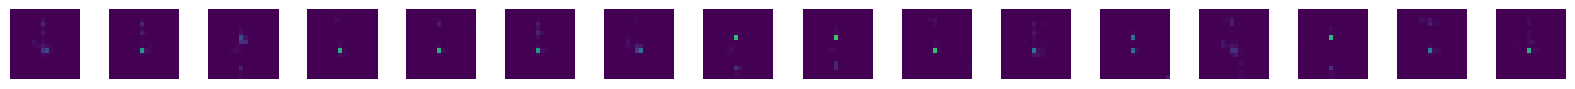

[Epoch 40/100] [D loss: 0.4378] [G loss: 1.2200] [Validity_loss: 1.1375] 
 [Stat_loss: 0.0207] [NNZ_loss: 0.0617]
Sample feature coding: [1.         1.5257413  0.15598725 0.42867777 0.55276054 0.00589281
 0.05829617 0.00367572 0.01645973]


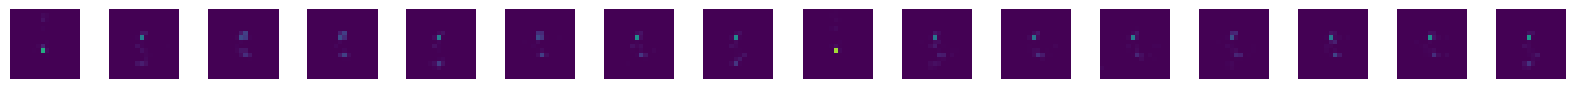

[Epoch 41/100] [D loss: 0.5103] [G loss: 1.0624] [Validity_loss: 0.9666] 
 [Stat_loss: 0.0156] [NNZ_loss: 0.0802]
Sample feature coding: [ 0.         -1.2437228   0.7970632   0.44515145  0.32730702  0.00991254
  0.0544888   0.00373551  0.03898146]


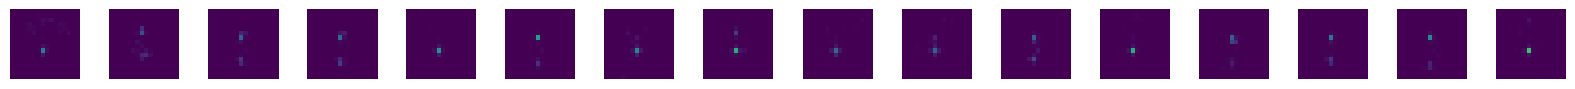

Model and statistics saved to models/class_gan_model_temp.pt
[Epoch 42/100] [D loss: 0.4809] [G loss: 1.2372] [Validity_loss: 1.1483] 
 [Stat_loss: 0.0066] [NNZ_loss: 0.0823]
Sample feature coding: [0.         1.0323774  0.07524744 0.1352853  0.6291744  0.01095002
 0.03931274 0.00410079 0.03579124]


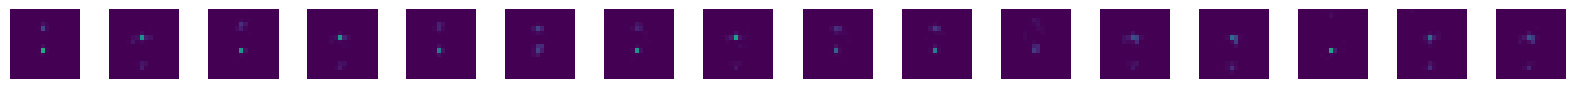

[Epoch 43/100] [D loss: 0.5999] [G loss: 1.2609] [Validity_loss: 0.9790] 
 [Stat_loss: 0.1968] [NNZ_loss: 0.0850]
Sample feature coding: [ 1.         -0.6469533   0.33363056  0.6212321   0.3716308   0.01135604
  0.08367042  0.00364556  0.03645361]


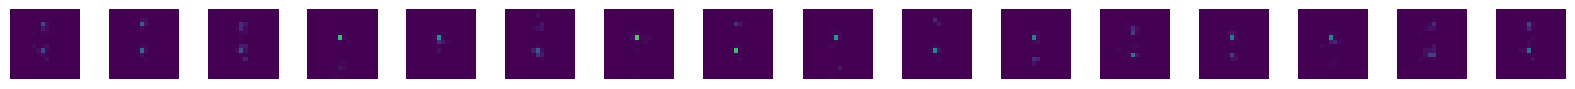

[Epoch 44/100] [D loss: 0.5734] [G loss: 1.0129] [Validity_loss: 0.9118] 
 [Stat_loss: 0.0014] [NNZ_loss: 0.0997]
Sample feature coding: [1.         0.88458693 0.04888854 0.38359424 0.3549076  0.00949421
 0.0462486  0.0038917  0.02155284]


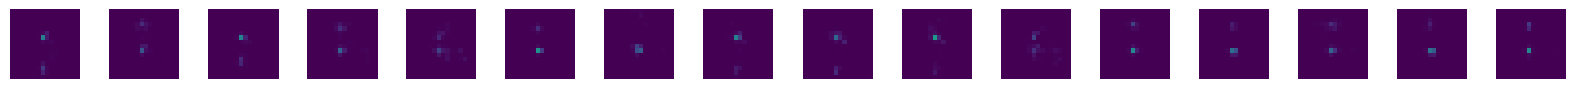

[Epoch 45/100] [D loss: 0.5495] [G loss: 1.1296] [Validity_loss: 1.0473] 
 [Stat_loss: 0.0089] [NNZ_loss: 0.0734]
Sample feature coding: [1.         1.1132549  0.00780231 0.71580285 0.3327457  0.00758999
 0.09219659 0.00378379 0.02924996]


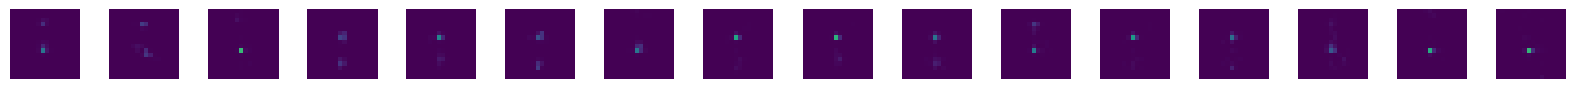

[Epoch 46/100] [D loss: 0.5429] [G loss: 1.0565] [Validity_loss: 0.9708] 
 [Stat_loss: 0.0100] [NNZ_loss: 0.0756]
Sample feature coding: [ 1.         -0.8465199   0.73315024  0.04899034  0.763104    0.01208558
  0.0622917   0.0037599   0.02198622]


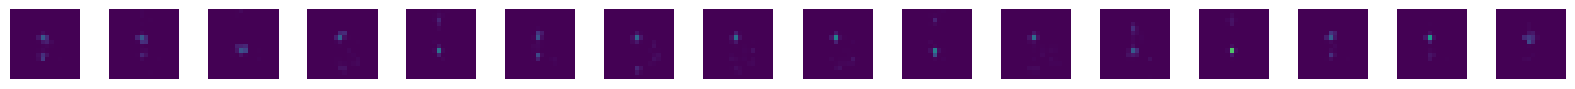

[Epoch 47/100] [D loss: 0.4685] [G loss: 1.2180] [Validity_loss: 1.0271] 
 [Stat_loss: 0.0922] [NNZ_loss: 0.0987]
Sample feature coding: [ 1.         -0.55430186  0.8813683   0.32403114  0.6859932   0.01068524
  0.05980203  0.00368308  0.02248886]


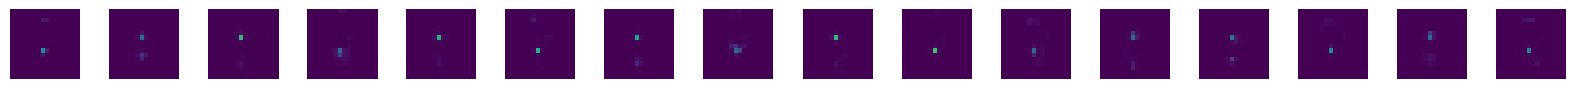

[Epoch 48/100] [D loss: 0.5430] [G loss: 1.0336] [Validity_loss: 0.9161] 
 [Stat_loss: 0.0399] [NNZ_loss: 0.0776]
Sample feature coding: [1.         0.8115308  0.9344104  0.09436871 0.49845135 0.00804753
 0.06641572 0.00416351 0.01939005]


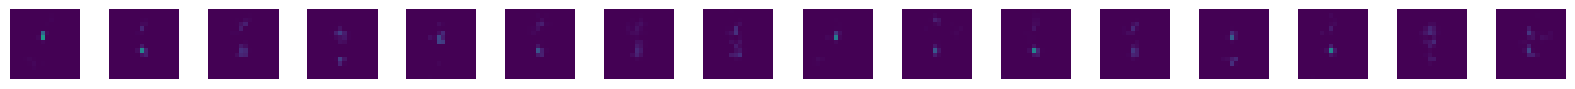

[Epoch 49/100] [D loss: 0.5437] [G loss: 1.0833] [Validity_loss: 1.0016] 
 [Stat_loss: 0.0104] [NNZ_loss: 0.0713]
Sample feature coding: [ 0.         -0.21433042  0.7435051   0.10109252  0.65935355  0.01251894
  0.03393935  0.00389931  0.03532792]


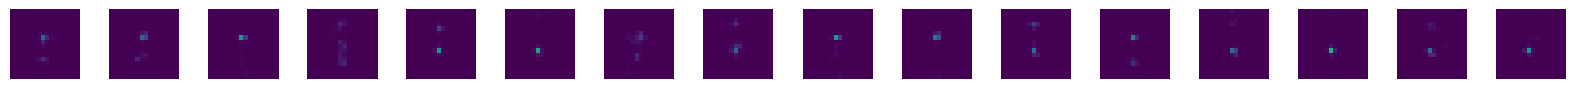

[Epoch 50/100] [D loss: 0.6037] [G loss: 1.0714] [Validity_loss: 0.9411] 
 [Stat_loss: 0.0340] [NNZ_loss: 0.0964]
Sample feature coding: [ 1.         -1.7665261   0.07882374  0.29522276  0.73464954  0.00992703
  0.02755807  0.00409767  0.02821295]


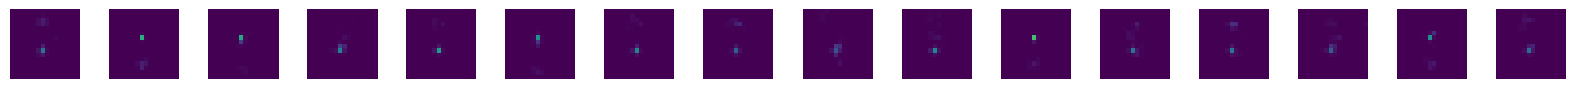

[Epoch 51/100] [D loss: 0.6059] [G loss: 1.0966] [Validity_loss: 1.0072] 
 [Stat_loss: 0.0111] [NNZ_loss: 0.0783]
Sample feature coding: [1.         0.07859109 0.33947435 0.36817688 0.62790734 0.00780673
 0.0546535  0.00385016 0.02158743]


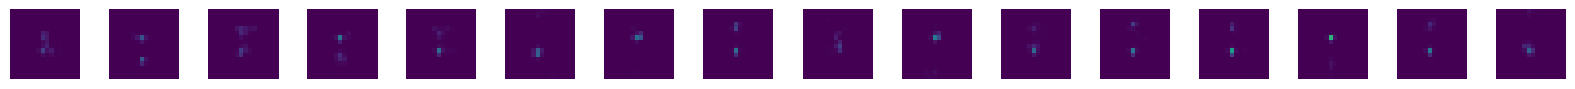

Model and statistics saved to models/class_gan_model_temp.pt
[Epoch 52/100] [D loss: 0.5491] [G loss: 1.1090] [Validity_loss: 0.9716] 
 [Stat_loss: 0.0421] [NNZ_loss: 0.0953]
Sample feature coding: [ 0.         -0.7134905   0.28849772  0.63872087  0.5773133   0.00764952
  0.04782343  0.00417798  0.02908438]


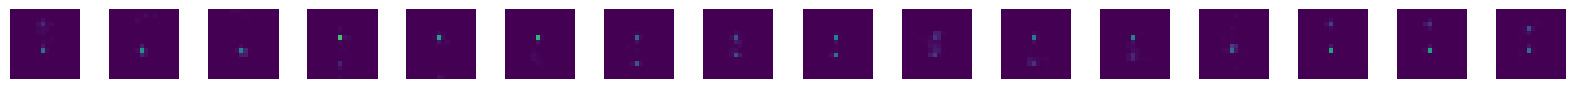

[Epoch 53/100] [D loss: 0.5561] [G loss: 0.9838] [Validity_loss: 0.9051] 
 [Stat_loss: 0.0117] [NNZ_loss: 0.0670]
Sample feature coding: [ 0.         -0.5834523   0.9926908   0.43430254  0.6142754   0.00912249
  0.07259581  0.00375745  0.04713021]


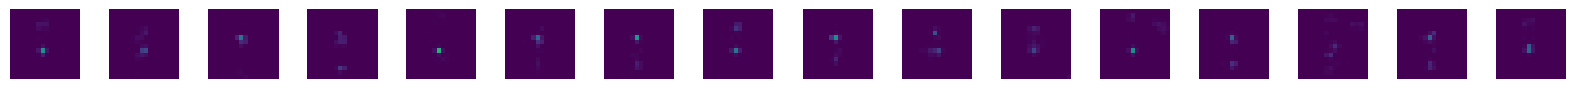

[Epoch 54/100] [D loss: 0.5803] [G loss: 1.0143] [Validity_loss: 0.8932] 
 [Stat_loss: 0.0364] [NNZ_loss: 0.0847]
Sample feature coding: [ 0.         -0.37124148  0.44761625  0.4172775   0.87262374  0.00706299
  0.04821966  0.00409724  0.02922217]


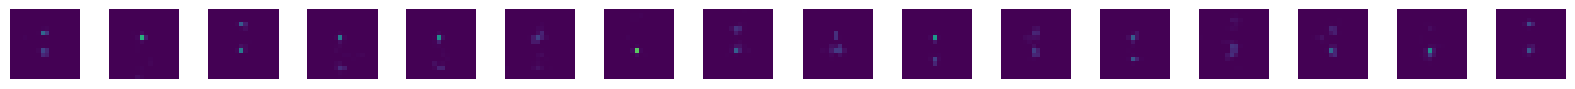

[Epoch 55/100] [D loss: 0.5001] [G loss: 1.1013] [Validity_loss: 1.0059] 
 [Stat_loss: 0.0116] [NNZ_loss: 0.0838]
Sample feature coding: [1.         0.80290973 0.7369034  0.35625723 0.51545703 0.01031577
 0.0380152  0.00417544 0.01372989]


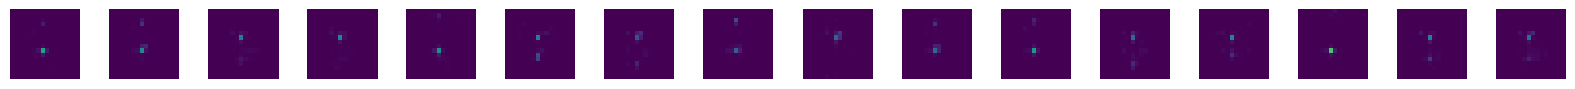

[Epoch 56/100] [D loss: 0.5620] [G loss: 1.0940] [Validity_loss: 0.9985] 
 [Stat_loss: 0.0023] [NNZ_loss: 0.0932]
Sample feature coding: [ 0.         -1.661698    0.20968787  0.74364114  0.70932996  0.01053462
  0.06353819  0.00389538  0.01711903]


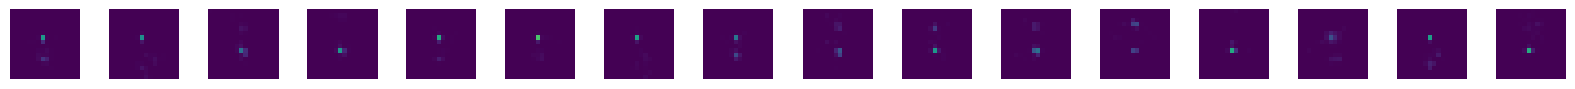

[Epoch 57/100] [D loss: 0.4989] [G loss: 1.1403] [Validity_loss: 1.0748] 
 [Stat_loss: 0.0012] [NNZ_loss: 0.0642]
Sample feature coding: [0.         1.7006192  0.55290526 0.4799961  0.5170812  0.00983583
 0.05108035 0.00417288 0.0325186 ]


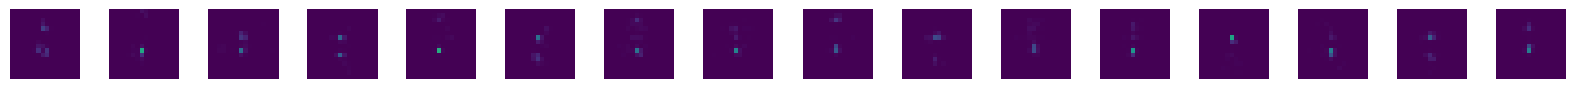

[Epoch 58/100] [D loss: 0.5251] [G loss: 1.1265] [Validity_loss: 1.0456] 
 [Stat_loss: 0.0130] [NNZ_loss: 0.0680]
Sample feature coding: [1.         0.6665565  0.6200743  0.03982449 0.55500257 0.0099773
 0.04304684 0.00373101 0.0203457 ]


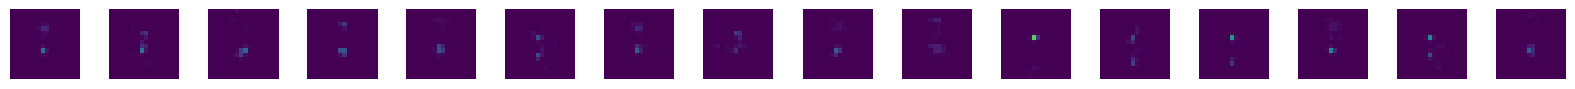

[Epoch 59/100] [D loss: 0.5408] [G loss: 1.1019] [Validity_loss: 0.9765] 
 [Stat_loss: 0.0251] [NNZ_loss: 0.1002]
Sample feature coding: [0.         1.821095   0.86847293 0.30414695 0.67476636 0.0089866
 0.04621724 0.0042396  0.02647064]


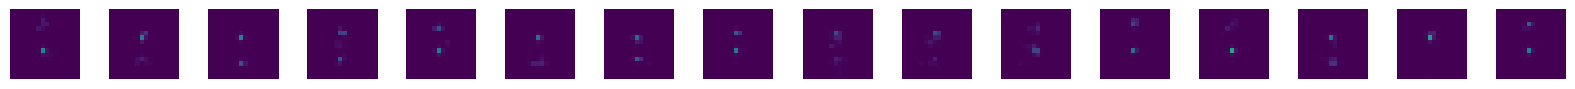

[Epoch 60/100] [D loss: 0.5321] [G loss: 1.0887] [Validity_loss: 0.9644] 
 [Stat_loss: 0.0304] [NNZ_loss: 0.0940]
Sample feature coding: [0.         0.10897841 0.5567134  0.63510805 0.60325813 0.01064889
 0.07554042 0.00407925 0.03885467]


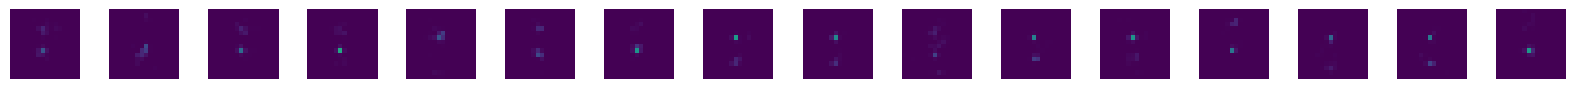

[Epoch 61/100] [D loss: 0.5339] [G loss: 1.1263] [Validity_loss: 1.0322] 
 [Stat_loss: 0.0166] [NNZ_loss: 0.0774]
Sample feature coding: [0.         1.5977262  0.10685322 0.40289217 0.43070647 0.01050227
 0.05733741 0.00389226 0.0360022 ]


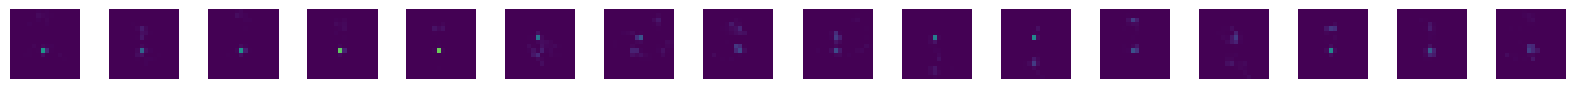

Model and statistics saved to models/class_gan_model_temp.pt
[Epoch 62/100] [D loss: 0.5585] [G loss: 1.1604] [Validity_loss: 1.0100] 
 [Stat_loss: 0.0693] [NNZ_loss: 0.0812]
Sample feature coding: [1.         0.21718226 0.86353123 0.46327928 0.38169494 0.01080655
 0.05130151 0.00359181 0.02423942]


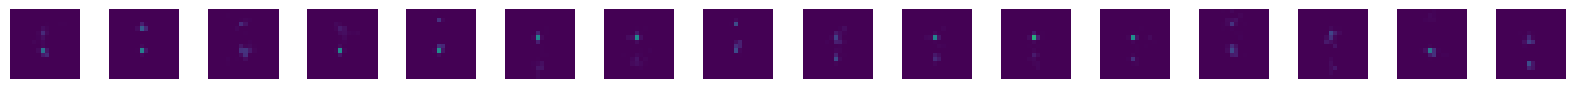

[Epoch 63/100] [D loss: 0.5452] [G loss: 1.0943] [Validity_loss: 0.9861] 
 [Stat_loss: 0.0170] [NNZ_loss: 0.0912]
Sample feature coding: [ 0.         -1.360068    0.14474268  0.48189133  0.40072483  0.01048837
  0.05746508  0.0038647   0.03322039]


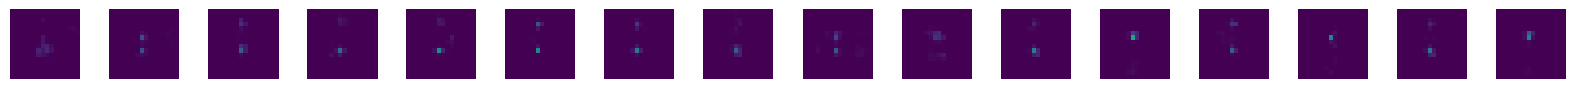

[Epoch 64/100] [D loss: 0.5698] [G loss: 1.0747] [Validity_loss: 0.9996] 
 [Stat_loss: 0.0081] [NNZ_loss: 0.0670]
Sample feature coding: [ 0.         -0.537896    0.4914768   0.59516543  0.43785876  0.00950131
  0.05836343  0.00381342  0.02067209]


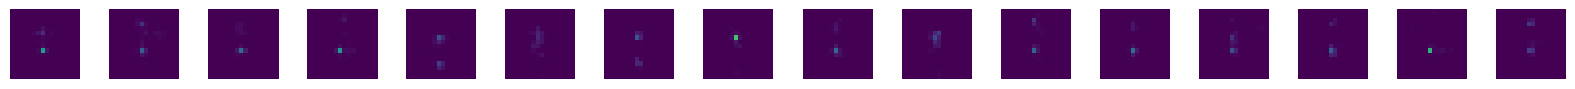

[Epoch 65/100] [D loss: 0.5368] [G loss: 1.2107] [Validity_loss: 1.1310] 
 [Stat_loss: 0.0114] [NNZ_loss: 0.0683]
Sample feature coding: [1.         0.29600722 0.70503956 0.50080657 0.37279102 0.01015843
 0.04571312 0.00362444 0.04105408]


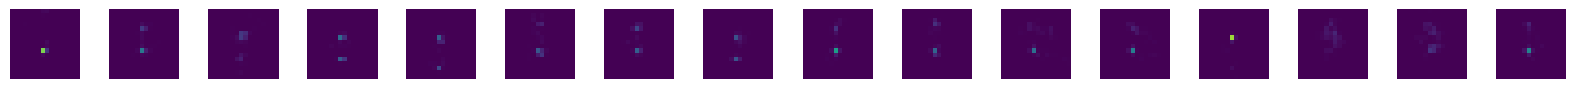

[Epoch 66/100] [D loss: 0.5350] [G loss: 1.0734] [Validity_loss: 0.9694] 
 [Stat_loss: 0.0198] [NNZ_loss: 0.0843]
Sample feature coding: [0.         0.55179924 0.9758157  0.4885815  0.91975254 0.00770535
 0.0631043  0.00337574 0.03272038]


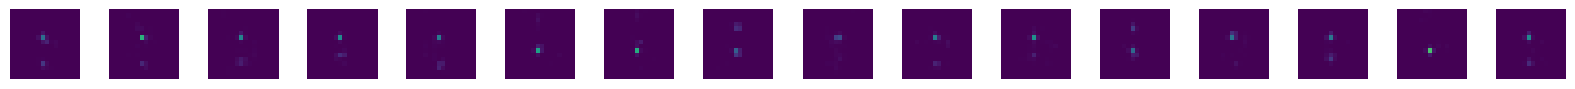

[Epoch 67/100] [D loss: 0.5217] [G loss: 1.1238] [Validity_loss: 1.0441] 
 [Stat_loss: 0.0053] [NNZ_loss: 0.0744]
Sample feature coding: [ 0.         -0.09366492  0.6873286   0.57014906  0.5648163   0.00970865
  0.05810547  0.00392806  0.03834664]


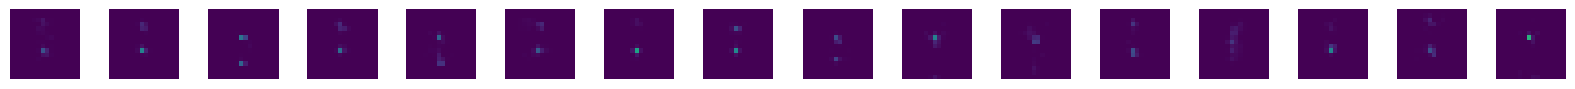

[Epoch 68/100] [D loss: 0.5096] [G loss: 1.1473] [Validity_loss: 1.0438] 
 [Stat_loss: 0.0028] [NNZ_loss: 0.1007]
Sample feature coding: [ 0.         -1.2223585   0.3269865   0.47583133  0.5179278   0.01103991
  0.05596449  0.00397058  0.02221094]


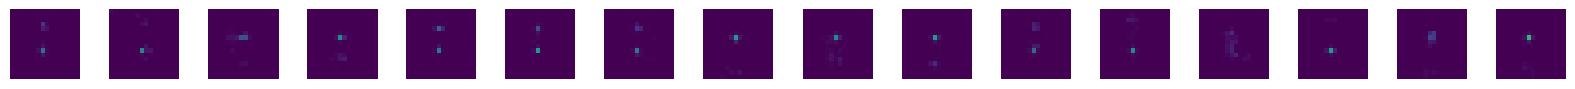

[Epoch 69/100] [D loss: 0.5006] [G loss: 1.2751] [Validity_loss: 1.1873] 
 [Stat_loss: 0.0062] [NNZ_loss: 0.0816]
Sample feature coding: [0.         1.0426913  0.7204166  0.40578526 0.76743716 0.01072366
 0.05358988 0.00406234 0.01592306]


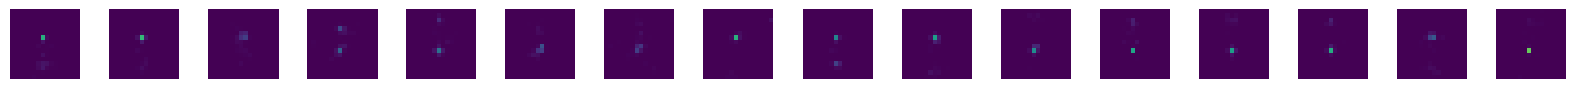

[Epoch 70/100] [D loss: 0.5021] [G loss: 1.1776] [Validity_loss: 1.0599] 
 [Stat_loss: 0.0410] [NNZ_loss: 0.0768]
Sample feature coding: [ 0.         -0.36209565  0.69736403  0.38395742  0.47014484  0.01034834
  0.08097155  0.0041242   0.02383056]


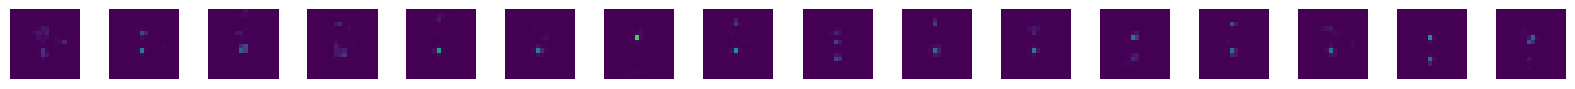

[Epoch 71/100] [D loss: 0.5015] [G loss: 1.0118] [Validity_loss: 0.9118] 
 [Stat_loss: 0.0095] [NNZ_loss: 0.0905]
Sample feature coding: [ 0.         -0.9720858   0.5834983   0.71833986  0.5659778   0.00921322
  0.03849073  0.00406859  0.04658198]


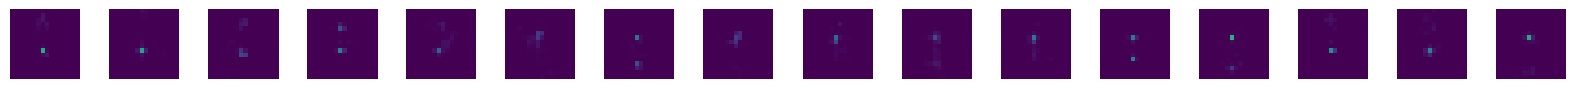

Model and statistics saved to models/class_gan_model_temp.pt
[Epoch 72/100] [D loss: 0.4723] [G loss: 1.1423] [Validity_loss: 1.0407] 
 [Stat_loss: 0.0179] [NNZ_loss: 0.0838]
Sample feature coding: [1.         1.4898967  0.5336637  0.22778489 0.8486386  0.00788996
 0.07245727 0.00360886 0.04390232]


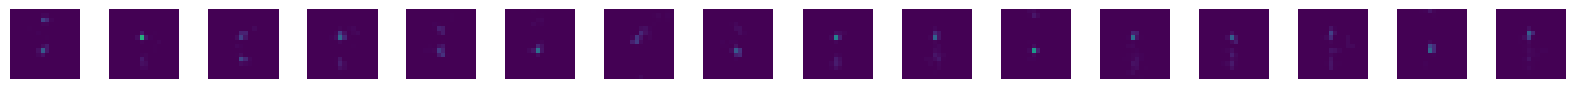

[Epoch 73/100] [D loss: 0.5256] [G loss: 1.2354] [Validity_loss: 1.0959] 
 [Stat_loss: 0.0452] [NNZ_loss: 0.0943]
Sample feature coding: [ 1.         -1.3600155   0.69195324  0.5761329   0.5275756   0.00872695
  0.05479336  0.00345272  0.02422196]


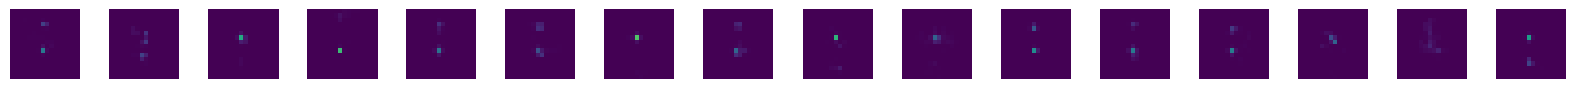

[Epoch 74/100] [D loss: 0.5163] [G loss: 1.3012] [Validity_loss: 1.0898] 
 [Stat_loss: 0.0962] [NNZ_loss: 0.1153]
Sample feature coding: [1.         0.49292356 0.7180413  0.00520891 0.67307705 0.00848498
 0.06703789 0.00415229 0.01957263]


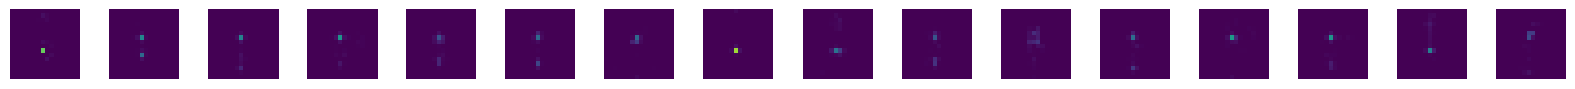

[Epoch 75/100] [D loss: 0.5980] [G loss: 1.1635] [Validity_loss: 1.0634] 
 [Stat_loss: 0.0151] [NNZ_loss: 0.0850]
Sample feature coding: [ 0.         -1.3205099   0.895333    0.54782695  0.4154819   0.00860866
  0.07070646  0.0036204   0.02295975]


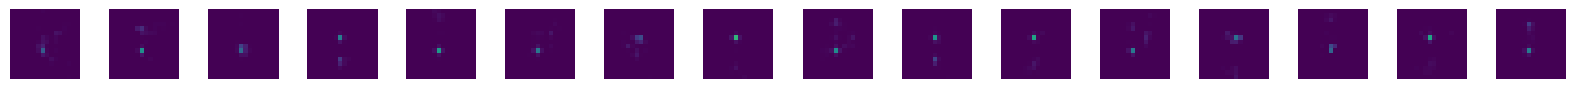

[Epoch 76/100] [D loss: 0.5251] [G loss: 1.0501] [Validity_loss: 0.9215] 
 [Stat_loss: 0.0418] [NNZ_loss: 0.0868]
Sample feature coding: [0.         1.70472    0.31524283 0.2857165  0.6669101  0.00802563
 0.03539666 0.00409069 0.04109829]


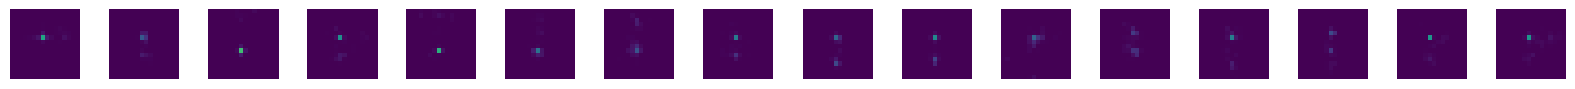

[Epoch 77/100] [D loss: 0.5111] [G loss: 1.1285] [Validity_loss: 1.0513] 
 [Stat_loss: 0.0071] [NNZ_loss: 0.0700]
Sample feature coding: [1.         1.9214159  0.10210454 0.09693126 0.98573214 0.00864
 0.07735314 0.00384619 0.03782034]


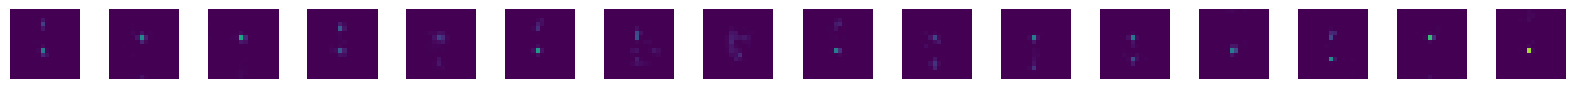

[Epoch 78/100] [D loss: 0.5671] [G loss: 1.1970] [Validity_loss: 1.0773] 
 [Stat_loss: 0.0253] [NNZ_loss: 0.0944]
Sample feature coding: [0.         1.1185209  0.39712253 0.3744037  0.8470219  0.0103071
 0.07783992 0.00388038 0.01524247]


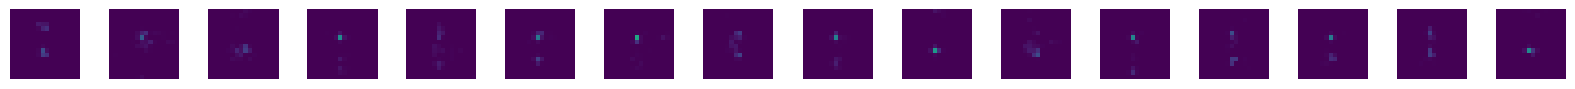

[Epoch 79/100] [D loss: 0.5463] [G loss: 1.0427] [Validity_loss: 0.9451] 
 [Stat_loss: 0.0292] [NNZ_loss: 0.0684]
Sample feature coding: [ 0.         -0.7397088   0.3961439   0.21149617  0.7460337   0.00997919
  0.0629188   0.00384519  0.01660499]


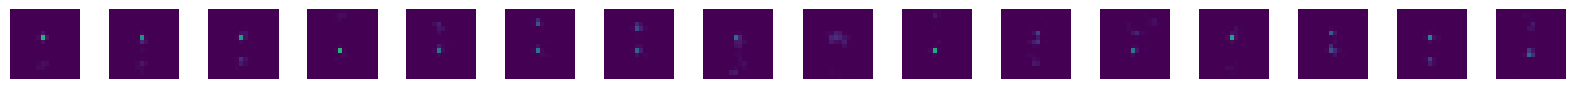

[Epoch 80/100] [D loss: 0.5116] [G loss: 1.2472] [Validity_loss: 1.1278] 
 [Stat_loss: 0.0173] [NNZ_loss: 0.1021]
Sample feature coding: [ 0.         -1.6612705   0.66363883  0.41636673  0.41201517  0.00752149
  0.06413678  0.00394028  0.03890867]


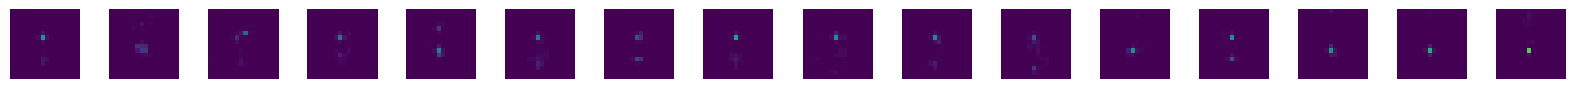

[Epoch 81/100] [D loss: 0.5533] [G loss: 1.1668] [Validity_loss: 1.0290] 
 [Stat_loss: 0.0567] [NNZ_loss: 0.0811]
Sample feature coding: [0.         1.21368    0.77542335 0.05425255 0.93266225 0.00731108
 0.0713477  0.00368621 0.03046995]


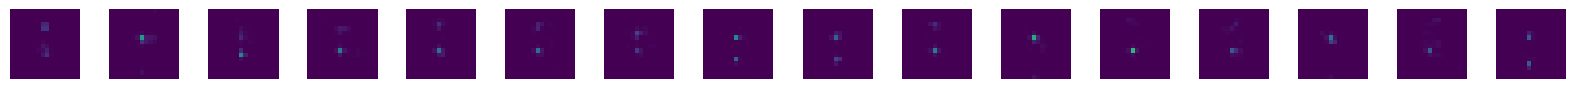

Model and statistics saved to models/class_gan_model_temp.pt
[Epoch 82/100] [D loss: 0.5068] [G loss: 1.1164] [Validity_loss: 1.0222] 
 [Stat_loss: 0.0049] [NNZ_loss: 0.0893]
Sample feature coding: [1.         1.0632873  0.73629117 0.45043588 0.6170751  0.00908117
 0.05171133 0.00412854 0.02095195]


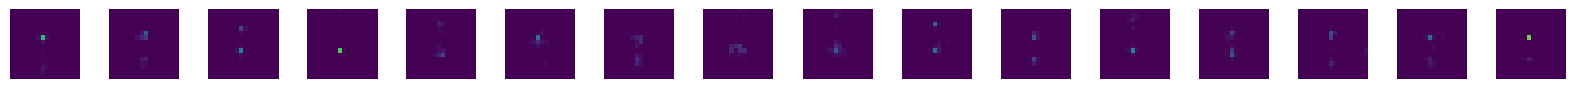

[Epoch 83/100] [D loss: 0.5139] [G loss: 1.2099] [Validity_loss: 1.1154] 
 [Stat_loss: 0.0028] [NNZ_loss: 0.0917]
Sample feature coding: [ 0.         -0.09220132  0.6180944   0.58015305  0.38199624  0.00994769
  0.07327574  0.00391957  0.02202311]


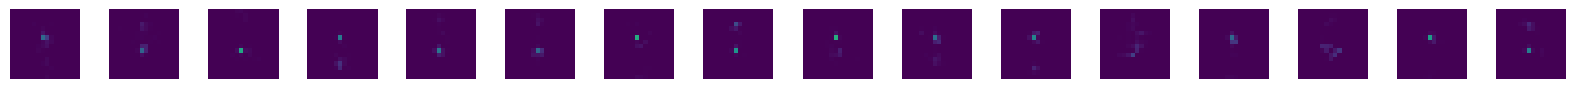

[Epoch 84/100] [D loss: 0.5284] [G loss: 1.1865] [Validity_loss: 1.0397] 
 [Stat_loss: 0.0598] [NNZ_loss: 0.0870]
Sample feature coding: [0.         1.2537727  0.65068185 0.88933694 0.6374442  0.00852708
 0.06911463 0.0041128  0.03267466]


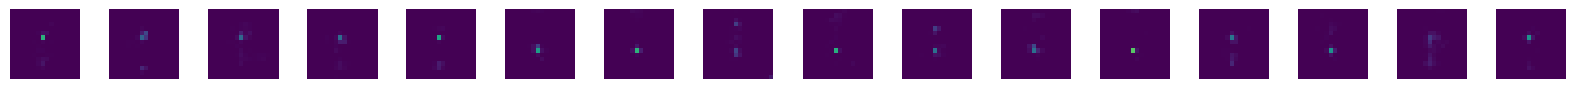

[Epoch 85/100] [D loss: 0.5357] [G loss: 1.2283] [Validity_loss: 1.0566] 
 [Stat_loss: 0.0512] [NNZ_loss: 0.1206]
Sample feature coding: [0.         0.5451634  0.513325   0.5809616  0.5333131  0.01015059
 0.03469633 0.00355303 0.02716343]


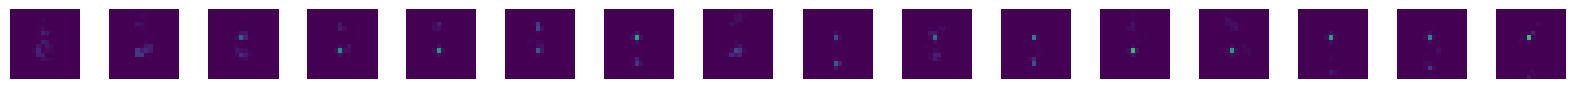

KeyboardInterrupt: 

In [7]:
if True:
    for epoch in range(n_epochs):
        for i, (real_image, real_features, flipped_image, flipped_features) in enumerate(dataloader):
            
            # All real data are normalized in the dataloader
            real_feat = real_features.to(device)
            real_flipped_feat = flipped_features.to(device)
            real_img = real_image.unsqueeze(1).to(device)
            real_flipped_img = flipped_image.unsqueeze(1).to(device)
    
            # print(f"Real: {real_img.shape}")
    
            # Codings should be label, eta, pT, mass that get passed directly to the discriminator
            # Other values get passed to the generator, then the output image passed to the discriminator
    
            # Discriminator training
            if i % 3 == 0:
                optimizer_D.zero_grad()
                discriminator.train()
                # Generate fake samples
                # Should be very easy to modify which values are passed as codings
                z_codings = torch.cat([torch.randint(0, 2, (batch_size, 1)), 
                                      sample_fit_noise(kdes, num_samples=batch_size)[:,:]],
                                      dim=1).to(device)
                # z_noise = torch.randn(batch_size, 5, ).to(device)
                # z_codings = torch.cat([z_codings, z_noise], dim=1)
    
                # Discriminator gets z_codings + generated_features
                fake_img = generator(z_codings)
                # print(f"Fake: {fake_img.shape}")
    
                # Generate eta-flipped data
                flipped_z_codings = z_codings.clone()
                flipped_z_codings[:, 1] *= -1
                
                fake_flipped_img = generator(flipped_z_codings)
    
                # Get predictions and labels
                real_disc_codings = real_feat[:,:num]
                real_flipped_disc_codings = real_flipped_feat[:,:num]
                fake_disc_codings = z_codings[:,:num]
                fake_flipped_disc_codings = flipped_z_codings[:,:num]
    
                real_pred = discriminator(real_img, real_disc_codings)
                real_flipped_pred = discriminator(real_flipped_img, real_flipped_disc_codings)
                fake_pred = discriminator(fake_img, fake_disc_codings)
                fake_flipped_pred = discriminator(fake_flipped_img, fake_flipped_disc_codings)
    
                preds = (torch.cat([real_pred, real_flipped_pred, fake_pred, fake_flipped_pred], dim=0)).squeeze(1)
    
                ones = torch.ones(2*len(fake_pred))
                zeros = torch.zeros(2*len(real_pred))
                labels = (torch.cat([ones, zeros], dim=0)).to(device)
    
                # Discriminator loss is just its ability to distinguish
                d_loss = torch.nn.BCELoss()(preds, labels)
    
                d_loss.backward()
                optimizer_D.step()
    
            # Generator Training
            if i % 1 == 0:
                optimizer_G.zero_grad()
                # generator.train()
                
                # Generate fake data
                # Should be very easy to modify which values are passed as codings
                z_codings = torch.cat([torch.randint(0, 2, (batch_size, 1)), 
                                      sample_fit_noise(kdes, num_samples=batch_size)[:,:]],
                                      dim=1).to(device)
                # z_noise = torch.randn(batch_size, 5, ).to(device)
                # z_codings = torch.cat([z_codings, z_noise], dim=1)
    
                # Discriminator gets z_codings + generated_features
                fake_img = generator(z_codings)
    
                # Generate eta-flipped data
                flipped_z_codings = z_codings.clone()
                flipped_z_codings[:, 1] *= -1
    
                fake_flipped_img = generator(flipped_z_codings)
    
                # Get predictions and labels
                fake_disc_codings = z_codings[:,:num]
                fake_flipped_disc_codings = flipped_z_codings[:,:num]
                
                # Fooled discriminator loss
                d_out = discriminator(fake_img, fake_disc_codings)
                d_out_flip = discriminator(fake_flipped_img, fake_flipped_disc_codings)
                real_pred = discriminator(real_img, real_disc_codings)
                real_flipped_pred = discriminator(real_flipped_img, real_flipped_disc_codings)
    
                target = torch.ones_like(d_out)
                bce = nn.BCELoss()
                validity_loss = bce(d_out, target) + bce(d_out_flip, target)
    
                ## Stat loss
                # Compute fake statistics
                fake_stats = compute_fake_statistics(fake_img.to('cpu'), dists.to('cpu'))
    
                fake_dR_mean = fake_stats['fake_dR_mean'].to(device)
                fake_dR_std = fake_stats['fake_dR_std'].to(device)
                fake_pixel_mean = fake_stats['fake_pixel_mean'].to(device)
                fake_pixel_std = fake_stats['fake_pixel_std'].to(device)
                
                # Get real stats from z_codings (features 5–8)
                real_dR_mean = z_codings[:,5]
                real_dR_std = z_codings[:,6]
                real_pixel_mean = z_codings[:,7]
                real_pixel_std = z_codings[:,8]
                
                real_stats = {
                    'real_dR_mean': real_dR_mean,
                    'real_dR_std': real_dR_std,
                    'real_pixel_mean': real_pixel_mean,
                    'real_pixel_std': real_pixel_std
                }
                
                # track_statistics(stats_dict, fake_stats, real_stats)
                # plot_tracked_statistics(stats_dict)
                
                if n_epochs - epoch <= 10:
                    # Track the last statistics
                    track_statistics(stats_dict, fake_stats, real_stats)
    
                # Statistical MSE loss
                # dR_mean_loss = (torch.nn.MSELoss()(fake_dR_mean, real_dR_mean) + torch.nn.MSELoss()(flipped_dR_mean, real_dR_mean))
                # dR_std_loss = (torch.nn.MSELoss()(fake_dR_std, real_dR_std) + torch.nn.MSELoss()(flipped_dR_std, real_dR_std))
                # pixel_mean_loss = (torch.nn.MSELoss()(fake_pixel_mean, real_pixel_mean) + torch.nn.MSELoss()(flipped_pixel_mean, real_pixel_mean))
                # pixel_std_loss = (torch.nn.MSELoss()(fake_pixel_std, real_pixel_std) + torch.nn.MSELoss()(flipped_pixel_std, real_pixel_std))
                
                # stat_loss = dR_mean_loss + dR_std_loss + 3*pixel_mean_loss + 2*pixel_std_loss
    
                # print(dR_mean_loss)
                # print(dR_std_loss)
                # print(3*pixel_mean_loss)
                # print(2*pixel_std_loss)
    
                # Statistical KL Divergence loss
                kl_total = 0
                kl1 = kde_kl_divergence_torch(real_dR_mean, fake_dR_mean) / 0.003
                # print(f"KL(real_dR_mean, fake_dR_mean) = {kl1.item()}")
                
                kl2 = kde_kl_divergence_torch(real_dR_std, fake_dR_std) / 0.003
                # print(f"KL(real_dR_std, fake_dR_std) = {kl2.item()}")
                
                kl3 = kde_kl_divergence_torch(real_pixel_mean, fake_pixel_mean) / 0.0025
                # print(f"KL(real_pixel_mean, fake_pixel_mean) = {kl3.item()}")
                
                kl4 = kde_kl_divergence_torch(real_pixel_std, fake_pixel_std) / 0.00015
                # print(f"KL(real_pixel_std, fake_pixel_std) = {kl4.item()}")
                
                kl_total = kl1 + kl2 + kl3 + kl4
    
                stat_loss = kl_total
                
                # Number non-zero loss
                fake_nnz = soft_count_nonzero(fake_img, threshold=3e-3, sharpness=10000.0)
                real_nnz = soft_count_nonzero(real_img, threshold=3e-3, sharpness=10000.0)
                nnz_loss = torch.nn.MSELoss()(fake_nnz, real_nnz)
    
                
                # Total generator loss is the average of the discriminator's predictions of the original and flipped data
                # + the difference between input and output dR and pixel statistics
    
                alpha = .4
                beta = .001
                chi = 1
    
                g_loss = (alpha*validity_loss + beta*nnz_loss + chi*stat_loss)
    
                g_loss.backward()
                optimizer_G.step()
    
        g_losses.append(g_loss.item())
        d_losses.append(d_loss.item())
    
        print(f"[Epoch {epoch+1}/{n_epochs}] [D loss: {d_losses[-1]:.4f}] [G loss: {g_losses[-1]:.4f}] [Validity_loss: {alpha*validity_loss:.4f}] \n [Stat_loss: {chi*stat_loss:.4f}] [NNZ_loss: {beta*nnz_loss:.4f}]") 
    
        plot_generated_samples(generator, dataset, kdes, batch_size=16, latent_dim=256)

        if epoch % 10 == 0:
            # Save model states and tracked data in a single file
            save_path = f"models/class_gan_model_temp.pt"
            torch.save({
                "generator_state_dict": generator.state_dict(),
                "discriminator_state_dict": discriminator.state_dict(),
                "g_losses": g_losses,
                "d_losses": d_losses,
                "stats_dict": stats_dict
            }, save_path)
            
            print(f"Model and statistics saved to {save_path}")
    
    plot_metrics(g_losses, d_losses)
    
    plot_tracked_statistics(stats_dict)

In [8]:
## Save Model
# Create output directory if it doesn't exist

save = True

if save:
    os.makedirs("models", exist_ok=True)

    # Timestamp for unique filenames
    timestamp = datetime.now().strftime("m%d_%H%M")
    
    # Save model states and tracked data in a single file
    save_path = f"models/class_gan_model_{timestamp}.pt"
    torch.save({
        "generator_state_dict": generator.state_dict(),
        "discriminator_state_dict": discriminator.state_dict(),
        "g_losses": g_losses,
        "d_losses": d_losses,
        "stats_dict": stats_dict
    }, save_path)
    
    print(f"Model and statistics saved to {save_path}")

Model and statistics saved to models/class_gan_model_m21_1003.pt


In [ ]:
plot_real_samples(dataset)

Sample feature coding: [0.         0.06271198 0.96732146 0.5711669  0.47858703 0.0105259
 0.03829399 0.00360104 0.02092074]


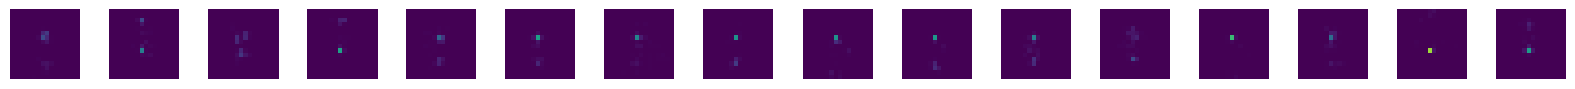

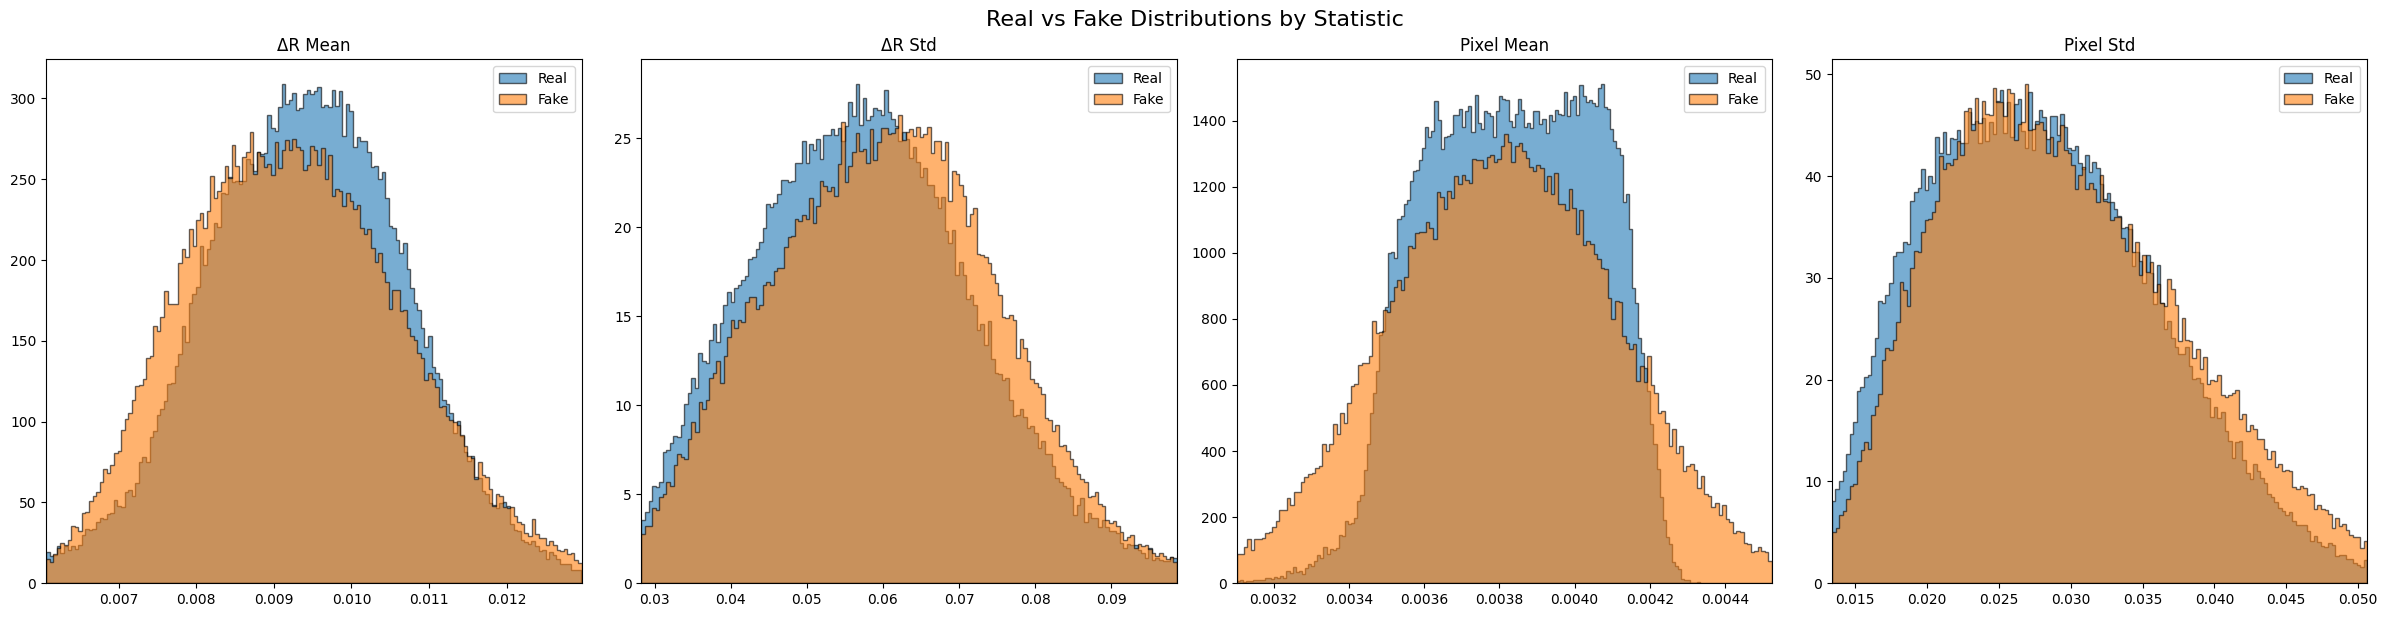

Discriminator output (wrong label): [0.69725615 0.34303537 0.40868294 ... 0.22792359 0.6024013  0.46617037]
Discriminator output (correct label): [0.81104326 0.39635363 0.39943188 ... 0.8322749  0.23587714 0.47676107]
Real labels: [1. 1. 1. ... 0. 0. 0.]
Swapped labels: [0. 0. 0. ... 0. 0. 0.]
Relative change (%): [-14.029723  -13.452196    2.3160577 ... -72.61438   155.38774
  -2.2213876]


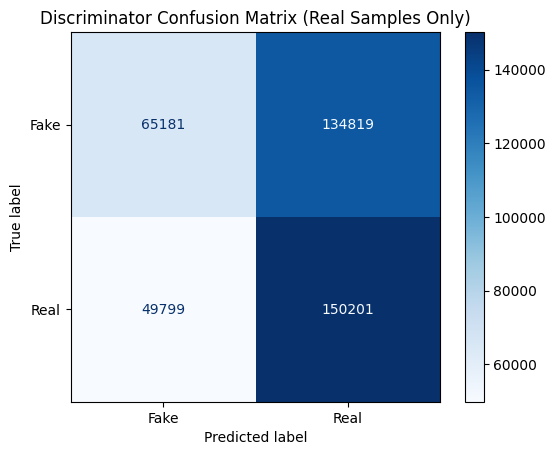

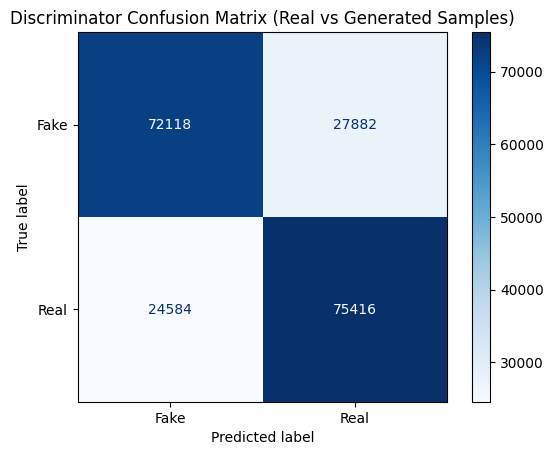

In [9]:
test_generated_samples(generator, discriminator, dataset, kdes, batch_size=100000)

# Optional args:
#     generator,
#     discriminator,
#     dataset,
#     kdes,
#     batch_size=16,
#     latent_dim=256,
#     codings=None,
#     plot_distributions=True,
#     compare_discriminator=True